## Part 2 – Product Comparison ##

In [1]:
import numpy as np
import pandas as pd 
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../data/snack_consumer_sensory_dataset.csv')
data.head()

,respondent_id,market,age,gender,product,overall_liking,sweetness,crunchiness,oiliness,aftertaste
0,10001,UK,34,Female,A_CrunchyClassic,7,3.0,6.1,5.5,3.9
1,10001,UK,34,Female,B_SweetSpicy,8,7.1,7.1,3.9,5.9
2,10001,UK,34,Female,C_LightBaked,4,3.1,6.5,4.6,2.9
3,10001,UK,34,Female,D_RichCheesy,3,5.2,4.1,6.3,6.0
4,10002,US,50,Female,A_CrunchyClassic,7,2.7,7.9,5.0,2.1


In [ ]:
# Simple random intercept model
model = smf.mixedlm(
    "overall_liking ~ product",
    data,
    groups=data["respondent_id"]
)

result = model.fit()
print(result.summary())


               Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   overall_liking
No. Observations:    880       Method:               REML          
No. Groups:          220       Scale:                1.6141        
Min. group size:     4         Log-Likelihood:       -1463.4885    
Max. group size:     4         Converged:            Yes           
Mean group size:     4.0                                           
-------------------------------------------------------------------
                        Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                6.055    0.086  70.685 0.000  5.887  6.222
product[T.B_SweetSpicy]  0.845    0.121   6.980 0.000  0.608  1.083
product[T.C_LightBaked]  0.641    0.121   5.291 0.000  0.403  0.878
product[T.D_RichCheesy] -1.495    0.121 -12.346 0.000 -1.733 -1.258
Group Var                0.000    0.035                        

d:\Evaluation-Task-CodeBricks\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


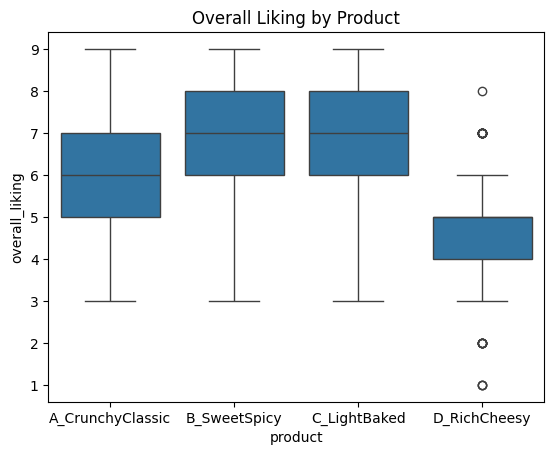

In [4]:

sns.boxplot(data=data, x='product', y='overall_liking')
plt.title("Overall Liking by Product")
plt.show()


<Axes: ylabel='Count'>

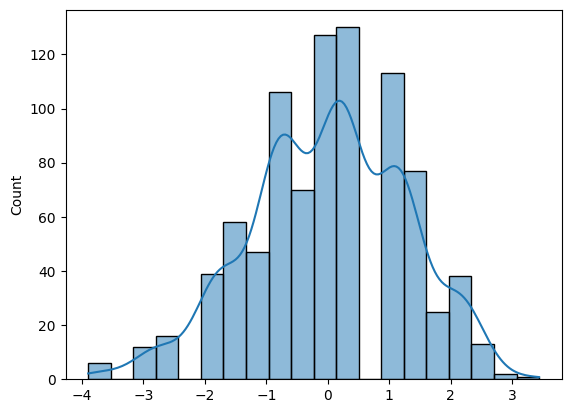

In [5]:
sns.histplot(result.resid, kde=True)


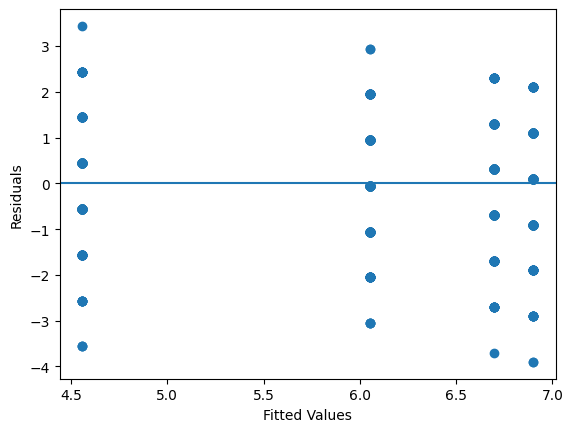

In [6]:
plt.scatter(result.fittedvalues, result.resid)
plt.axhline(0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()
